# Two-guard / one-bandit demo — particle-filter beliefs with extension hooks

This notebook is a **scaffold for collaborator extensions**. It runs
the Lady-Bandit-Guard scenario with **2 randomly-initialized guards**
and **1 lady-seeking bandit**, each side carrying a particle-filter
belief about the opposing side. Every knob the collaborator is likely
to want to twist — sensor ranges, measurement noise, capture / breach
radii, the guard policy, the bandit policy, the reward, and the
belief-fusion hook — is consolidated into a small number of clearly
labelled cells near the top.

**Where to look first:** all extension points are tagged with the
string `EXTENSION POINT` in the section heading. Search the notebook
for that string to find every place the collaborator is expected to
substitute their own logic.

**What's modelled:**

- 2 guards on small co-orbiting rings near the lady (RTN origin),
  phases sampled uniformly at random per run.
- 1 bandit on the outer 2:1 RT-plane natural-motion ring; the bandit
  runs a glideslope policy that closes on the lady at a speed set by
  the range and by its own braking authority.
- Each guard runs a `RangeLimitedObservation` with a tunable sensor
  range and measurement noise; the bandit's sensor parameters are
  tuned independently.
- Each guard maintains a `ParticleFilterBelief` over the bandit, with
  the prior initialized **uniformly on the bandit ring** — the PF
  expresses this prior exactly while a Gaussian KF cannot (it would
  collapse the ring to a useless centroid).
- The bandit also maintains a particle-filter belief over each guard.

**What's not modelled (collaborator can add):**

- Communication-aware actions / cost. The action space already
  supports `COMMUNICATE` (see `with_communication=True` in the
  `make_lady_bandit_guard` builder), but this notebook keeps comms
  passive.
- Per-vehicle sensor ranges within a side. `RangeLimitedObservation`
  currently uses one range per channel; to give guard 0 a different
  range than guard 1 you would need to extend the observation fn
  (the layout already carries `n_self`, so it's a small change).

CPU-only, like the other LBG notebooks.

In [ ]:
# Pin CPU device before importing JAX. On Apple Silicon `jax-mps` may
# auto-register and become the default; the float64 reference-orbit
# arrays would then hit MLX and error.
import os

os.environ["JAX_DEFAULT_DEVICE"] = "cpu"

import sys
from pathlib import Path

_here = Path.cwd()
if (_here / "src" / "orbitalgym").is_dir():
    _repo_root = _here
elif (_here.parent / "src" / "orbitalgym").is_dir():
    _repo_root = _here.parent
else:
    raise RuntimeError(f"Could not locate OrbitalGym repo root from cwd={_here}")
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

%load_ext autoreload
%autoreload 2

from dataclasses import dataclass  # noqa: E402
from types import SimpleNamespace  # noqa: E402
from typing import Any  # noqa: E402

import jax  # noqa: E402
import jax.numpy as jnp  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
from matplotlib.patches import Circle  # noqa: E402

from orbitalgym import (  # noqa: E402
    Actions,
    BySide,
    OrbitalGymEnv,
    ScenarioConfig,
    Side,
    VehicleParamsSpec,
)
from orbitalgym.belief import (  # noqa: E402
    ParticleFilterBeliefUpdater,
    ParticleFilterRingInitializer,
    PFTeamFusion,
)
from orbitalgym.dynamics.hcw import hcw_rt_step  # noqa: E402
from orbitalgym.games.lady_bandit_guard import LadyBanditGuard  # noqa: E402
from orbitalgym.observations.negative_info import Hard  # noqa: E402
from orbitalgym.observations.range_limited import RangeLimitedObservation  # noqa: E402
from orbitalgym.policies.heuristic.glideslope import (  # noqa: E402
    clip_to_cap,
    glideslope_u,
)
from orbitalgym.policies.zero import ZeroControl  # noqa: E402
from orbitalgym.reference_orbit import (  # noqa: E402
    ReferenceOrbitState,
)
from orbitalgym.reference_orbit import (  # noqa: E402
    mean_motion as ref_mean_motion,
)
from orbitalgym.registry import DynamicsKey, StateComponentKey  # noqa: E402
from orbitalgym.sampling.mass import ConstantMass  # noqa: E402
from orbitalgym.sampling.side import RelativeEllipse  # noqa: E402
from orbitalgym.sampling.spec import ICSpec  # noqa: E402
from orbitalgym.termination.lbg_events import LbgEventTermination  # noqa: E402
from orbitalgym.termination.max_distance import (  # noqa: E402, E501
    AnyOfTermination,
    MaxDistanceTermination,
)

## 1. Knobs — TUNE THIS CELL

Everything you'd typically want to sweep lives here. The sections
below build the scenario from these constants without any other
magic numbers. The notebook is intentionally written so re-running
from this cell down picks up any change.

In [ ]:
# ---- Geometry ---------------------------------------------------------------
# Bandit ring: under HCW the along-track extent is 2x the radial extent
# (the 2:1 RT-plane natural-motion ellipse). With RING_RADIUS_M=4000 the
# bandit starts 8 km along-track from the lady at phase=pi/2 (max-distance
# phase), giving a longer approach window than the 2-km baseline.
RING_RADIUS_M = 4000.0  # bandit's natural-motion ring (radial extent)
GUARD_RING_RADIUS_M = 1000.0  # guard's small co-orbiting ring near the lady

# ---- Sensor parameters (per side) -------------------------------------------
# Each side carries its own RangeLimitedObservation channel; sensor
# range and measurement noise are independently tunable. To give the
# bandit a "weaker" sensor than the guards (more realistic) reduce
# BANDIT_SENSOR_RANGE_M. See section 9 for known limits (no per-vehicle
# ranges within a side without extending the observation fn).
GUARD_SENSOR_RANGE_M = 2200.0  # guards see the bandit only when within this radius
GUARD_SIGMA_RANGE = 5.0  # guards' position-measurement std (m) when visible

BANDIT_SENSOR_RANGE_M = 1500.0  # bandit's sensor range — typically tighter than the guards'
BANDIT_SIGMA_RANGE = 10.0  # bandit's measurement std (m) when visible

# ---- Capture / breach radii (REWARD-SHAPING KNOBS) --------------------------
# These are the *terminal-event* radii used by both the default LBG reward
# and the LBG termination function. Increasing CATCH_RADIUS_M makes the
# guard's task easier; decreasing BREACH_RADIUS_M makes the bandit's task
# harder. See section 6 for the reward / termination wiring.
CATCH_RADIUS_M = 50.0  # guard "catches" the bandit when within this distance
BREACH_RADIUS_M = 5.0  # bandit "breaches" the lady when within this distance

# ---- Runaway-drift cap -------------------------------------------------------
# The bandit's lady-seeking policy can drive secular drift in the rotating
# frame; without a cap the rollout wanders to tens of km and the
# visualization becomes useless. Episodes also end when ANY vehicle (guard
# or bandit) exceeds this distance from the lady — this surfaces "the
# bandit ran away" / "a guard got slung out" failures cleanly.
MAX_DISTANCE_TERMINATION_M = 20000.0  # 20 km — about 2.5x the along-track ring extent

# ---- Bandit thrust authority ------------------------------------------------
# Per-step Δv cap (m/s) on the bandit's glideslope controller. The cap
# also sets the braking curve `sqrt(2 * brake_fraction * max_dv / dt * rho)`,
# so it bounds the closing speed the controller is willing to build up as
# well as the impulse it can spend in one step. Too tight a cap leaves the
# bandit thrusting flat out for the whole approach, which behaves like the
# naïve "thrust toward origin" policy and fails under HCW Coriolis. The
# default 0.5 m/s lets it come off the cap early enough to fly the
# glideslope and close on the lady in roughly one orbital period.
BANDIT_MAX_DV_MPS = 0.5

# ---- Bandit guard-avoidance (APF) -------------------------------------------
# The bandit's policy is glideslope-toward-lady PLUS a Gaussian-decay
# repulsion away from each guard ("artificial potential field" / APF).
# `BANDIT_AVOIDANCE_GAIN` is the peak repulsive Δv (m/s) when the guard
# is at zero distance — clipped by `BANDIT_MAX_DV_MPS` like every other
# action. `BANDIT_AVOIDANCE_SIGMA_M` is the Gaussian length scale: at
# `~3*sigma` the repulsion is essentially zero, at `~sigma` it is ~37%,
# at zero it is full `gain`. Set `BANDIT_AVOIDANCE_GAIN=0` to turn
# avoidance off and recover the pure lady-seeking glideslope.
#
# Tuning intuition: with sigma=300m and gain=1.0, the bandit feels a
# repulsion of >0.1 m/s within ~700m of a guard. The guards on the 200m
# ring around the lady create a "soft wall" the bandit must work around
# — exactly the trade-off the user wants to surface so SDecZero-style
# guard policies can tip the balance.
BANDIT_AVOIDANCE_GAIN = 1.0
BANDIT_AVOIDANCE_SIGMA_M = 300.0

# ---- Time / horizon ----------------------------------------------------------
DT = 10.0  # integration step (s)
MAX_HORIZON_S = 4500.0  # ~75 min — just over one orbital period

# ---- Particle filter ---------------------------------------------------------
N_PARTICLES = 256
PROCESS_NOISE_DIAG = jnp.array([1.0, 1.0, 1e-3, 1e-3])  # (r, t, rdot, tdot)

# ---- Fleet sizing ------------------------------------------------------------
N_GUARDS = 2
N_BANDITS = 1

# ---- Reference orbit ---------------------------------------------------------
ref_orbit = ReferenceOrbitState(
    position_eci=jnp.array([7000e3, 0.0, 0.0]),
    velocity_eci=jnp.array([0.0, 7.5e3, 0.0]),
)
N_MOTION = float(ref_mean_motion(ref_orbit))
print(
    f"mean motion = {N_MOTION:.4e} rad/s   (orbital period ~ {2 * np.pi / N_MOTION / 60:.1f} min)"
)

## 2. Scenario builder

Guards are placed at **stratified random phases** on their small ring
(n=2 -> phases [phi, phi + pi]) where phi is a per-seed uniform-random
base phase. This gives randomness across seeds while guaranteeing the
two guards never collide visually -- fully-uniform phase_rad=None can
yield near-coincident phases on small rings.

`termination_fn` is composed: **either** an LBG event (catch /
breach) **or** a max-distance runaway-drift cap fires the
termination. The first event to trigger ends the episode.

In [3]:
def stratified_random_phases(seed: int, n: int) -> jnp.ndarray:
    """`n` evenly-spaced phases (2*pi/n apart), with a per-seed random rotation.

    Guarantees the spread (no two phases coincide) while letting the
    geometry vary across seeds. For n=2 this yields [phi, phi + pi].
    """
    base = jax.random.uniform(jax.random.PRNGKey(seed), (), minval=0.0, maxval=2 * jnp.pi)
    return base + jnp.arange(n) * (2.0 * jnp.pi / n)


def make_cfg(*, guard_obs_fn=None, bandit_obs_fn=None, seed: int = 0):
    """Build a 2-guard / 1-bandit ScenarioConfig.

    Guards: small ring at GUARD_RING_RADIUS_M, stratified random phases
    derived from `seed`. Bandit: outer 2:1 ring at RING_RADIUS_M, phase
    = pi/2 (max-distance start). Termination = LbgEventTermination
    (catch / breach) OR MaxDistanceTermination (runaway-drift cap),
    whichever fires first.
    """
    guard_phases = stratified_random_phases(seed, N_GUARDS)
    return ScenarioConfig(
        n_guards=N_GUARDS,
        n_bandits=N_BANDITS,
        epoch_mjd_utc=60067.0,
        reference_orbit=ref_orbit,
        guard_components=(StateComponentKey.RT, StateComponentKey.MASS),
        bandit_components=(StateComponentKey.RT, StateComponentKey.MASS),
        guard_params=VehicleParamsSpec(dry_mass_kg=12.0, isp_s=65.0, max_thrust_n=3.6),
        bandit_params=VehicleParamsSpec(dry_mass_kg=12.0, isp_s=65.0, max_thrust_n=3.6),
        ic_sampler=ICSpec(
            guard_sampler=RelativeEllipse(
                radial_ellipse_m=GUARD_RING_RADIUS_M,
                cross_track_m=0.0,
                along_track_offset_m=0.0,
                phase_rad=guard_phases,  # stratified random per seed
                mass_sampler=ConstantMass(propellant_mass_kg=3.0),
            ),
            bandit_sampler=RelativeEllipse(
                radial_ellipse_m=RING_RADIUS_M,
                cross_track_m=0.0,
                along_track_offset_m=0.0,
                phase_rad=jnp.array([jnp.pi / 2.0]),  # max-distance phase
                mass_sampler=ConstantMass(propellant_mass_kg=3.0),
            ),
            validators=(),
            max_attempts=10,
        ),
        truth_dynamics=DynamicsKey.HCW_RT,
        policy_dynamics=DynamicsKey.HCW_RT,
        guard_observation_fn=guard_obs_fn,
        bandit_observation_fn=bandit_obs_fn,
        dt=DT,
        max_horizon_s=MAX_HORIZON_S,
        seed=seed,
        game=LadyBanditGuard(
            breach_radius_m=BREACH_RADIUS_M,
            catch_radius_m=CATCH_RADIUS_M,
        ),
        termination_fn=AnyOfTermination(
            [
                LbgEventTermination(
                    breach_radius_m=BREACH_RADIUS_M,
                    catch_radius_m=CATCH_RADIUS_M,
                ),
                MaxDistanceTermination(max_distance_m=MAX_DISTANCE_TERMINATION_M),
            ]
        ),
    )


# Build a proto config to read .layout, then attach observation fns.
proto_layout = OrbitalGymEnv(make_cfg()).layout
guard_obs_fn = RangeLimitedObservation(
    layout=proto_layout,
    sensor_range_m=GUARD_SENSOR_RANGE_M,
    sigma_range=GUARD_SIGMA_RANGE,
)
bandit_obs_fn = RangeLimitedObservation(
    layout=proto_layout,
    sensor_range_m=BANDIT_SENSOR_RANGE_M,
    sigma_range=BANDIT_SIGMA_RANGE,
)
cfg = make_cfg(guard_obs_fn=guard_obs_fn, bandit_obs_fn=bandit_obs_fn)
env = OrbitalGymEnv(cfg)
print(f"n_guards={cfg.n_guards}  n_bandits={cfg.n_bandits}")
print(f"guard sensor: range={GUARD_SENSOR_RANGE_M:.0f} m  sigma={GUARD_SIGMA_RANGE:.1f} m")
print(f"bandit sensor: range={BANDIT_SENSOR_RANGE_M:.0f} m  sigma={BANDIT_SIGMA_RANGE:.1f} m")
print(
    f"catch_radius={CATCH_RADIUS_M:.0f} m  breach_radius={BREACH_RADIUS_M:.0f} m  "
    f"max_distance={MAX_DISTANCE_TERMINATION_M:.0f} m"
)

n_guards=2  n_bandits=1
guard sensor: range=2200 m  sigma=5.0 m
bandit sensor: range=1500 m  sigma=10.0 m
catch_radius=50 m  breach_radius=5 m  max_distance=20000 m


## 3. EXTENSION POINT — Bandit policy: glideslope + guard avoidance (APF)

The bandit balances two competing goals:

1. **Reach the lady.** Modeled by a glideslope: the commanded closing
   speed grows linearly with range and is capped by the braking curve
   the bandit's own Δv budget can shed.
2. **Avoid the guards.** Modeled by an artificial potential field
   (APF) — a sum of repulsive Δv contributions, one per guard, with
   Gaussian decay in the bandit-to-guard distance.

Why this split? The glideslope commands a velocity along the line of
sight to the lady, so there is nowhere inside it to express "stay away
from a guard", which depends on geometry the line of sight ignores.
Adding the repulsion on top keeps the per-step cost at a handful of
elementwise operations:

```text
  rho     = ||x_b[:2]||                         (range to the lady)
  s       = min(rho / slope_s + arrival_mps, sqrt(2 a_brake rho))
  u_glide = -s * rho_hat - x_b[2:]              (lady-seeking, unclipped)
  u_avoid = sum_g  g·exp(-d_g^2/(2sigma^2)) · (x_b - x_g)/||x_b - x_g||
  u       = clip_norm(u_glide + u_avoid, max_dv)
```

`a_brake = brake_fraction * max_dv / dt`. The gain, `slope_s` and
`arrival_mps`, does not depend on `max_dv`: the budget enters only
through the braking curve and the single norm clip on the sum.

Tuning knobs (in section 1):

- `BANDIT_AVOIDANCE_GAIN` — peak repulsive Δv when the bandit is on
  top of a guard. Set to 0 to recover the pure lady-seeking glideslope.
- `BANDIT_AVOIDANCE_SIGMA_M` — Gaussian length scale; repulsion is
  ~37% of `gain` at distance sigma, ~14% at 2*sigma, ~1% at 3*sigma.

**Bandit perceives guards via TRUTH in this demo.** The agent_view
passed in section 7 is a tuple `(bandit_rt, guard_pos_truth)`. To
move the bandit to a *belief*-based perception, swap
`state.guards.rt[:, :2]` for the bandit's PF cross-pair mean over
the guards.

Drop-in replacements:

- **Pure glideslope (no avoidance)**: set `BANDIT_AVOIDANCE_GAIN = 0` in
  section 1. Equivalent to the previous demo's policy.
- **`GoToLadyPolicyNaive`** — naïve "thrust toward origin" — visibly
  drifts the bandit AWAY from the lady due to HCW Coriolis coupling.
  Useful for the educational ablation.
- **A POMDP solver** — replace the policy entirely; pass a belief as
  `agent_view`. This is the integration target for SDecZero.

In [4]:
@dataclass(frozen=True)
class GlideslopeToLadyWithAvoidance:
    """Glideslope toward the lady + Gaussian-repulsion APF away from guards.

    `agent_view` is a tuple `(bandit_rt, guard_pos)`:
        bandit_rt:   shape (n_bandits, 4) — RT-frame state.
        guard_pos:   shape (n_guards, 2)  — RT-frame positions only.

    The lady-seeking term is the glideslope impulse toward the RTN origin:
    the commanded closing speed is the smaller of `rho / slope_s +
    arrival_mps` and the braking curve `sqrt(2 * a_brake * rho)` the
    per-step cap can shed, with `a_brake = brake_fraction * max_dv_mps / dt`.
    The repulsion sums a Gaussian decay away from each guard:
        magnitude = avoidance_gain * exp(-d^2 / (2*sigma^2))
        direction = (bandit_pos - guard_pos) / ||bandit_pos - guard_pos||
    The guidance impulse is left unclipped so the repulsion competes with it
    on equal terms; their sum is scaled down to Euclidean norm `max_dv_mps`
    once, when it exceeds it. Setting `avoidance_gain=0` recovers the pure
    glideslope.

    The gain, `slope_s` and `arrival_mps`, does not depend on `max_dv_mps`:
    the cap enters only through the braking curve and the final clip.
    """

    dt: float
    mean_motion: float
    slope_s: float
    arrival_mps: float
    brake_fraction: float
    hcw_fraction: float
    max_dv_mps: float
    avoidance_gain: float
    avoidance_sigma_m: float
    n_vehicles: int = 1
    command_cls: Any = None

    @classmethod
    def build(
        cls,
        *,
        dt,
        mean_motion,
        slope_s=100.0,
        arrival_mps=0.3,
        brake_fraction=0.5,
        hcw_fraction=0.5,
        max_dv_mps=0.5,
        avoidance_gain=1.0,
        avoidance_sigma_m=300.0,
        n_vehicles=1,
        command_cls=None,
    ):
        return cls(
            dt=float(dt),
            mean_motion=float(mean_motion),
            slope_s=float(slope_s),
            arrival_mps=float(arrival_mps),
            brake_fraction=float(brake_fraction),
            hcw_fraction=float(hcw_fraction),
            max_dv_mps=float(max_dv_mps),
            avoidance_gain=float(avoidance_gain),
            avoidance_sigma_m=float(avoidance_sigma_m),
            n_vehicles=n_vehicles,
            command_cls=command_cls,
        )

    def __call__(self, policy_state, agent_view, key, t):
        del key, t
        if self.command_cls is None:
            raise ValueError("GlideslopeToLadyWithAvoidance was constructed without command_cls.")
        bandit_rt, guard_pos = agent_view  # (n_b, 4), (n_g, 2)

        # ---- Lady-seeking (glideslope, unclipped) ----
        u_glide = glideslope_u(
            bandit_rt,
            jnp.zeros_like(bandit_rt),
            max_dv_mps=self.max_dv_mps,
            dt=self.dt,
            mean_motion=self.mean_motion,
            slope_s=self.slope_s,
            arrival_mps=self.arrival_mps,
            brake_fraction=self.brake_fraction,
            hcw_fraction=self.hcw_fraction,
        )

        # ---- Guard avoidance (APF) ----
        # diff[b, g, :] = bandit_pos[b] - guard_pos[g]; shape (n_b, n_g, 2)
        bandit_pos = bandit_rt[:, None, :2]
        gp = guard_pos[None, :, :]
        diff = bandit_pos - gp
        dist = jnp.linalg.norm(diff, axis=-1, keepdims=True)  # (n_b, n_g, 1)
        direction = diff / (dist + 1e-9)
        sigma = self.avoidance_sigma_m
        magnitude = self.avoidance_gain * jnp.exp(-(dist**2) / (2.0 * sigma**2))
        u_avoid = (magnitude * direction).sum(axis=1)  # (n_b, 2)

        dvs = clip_to_cap(u_glide + u_avoid, self.max_dv_mps)
        cmd_template = self.command_cls.zeros(self.n_vehicles)
        return cmd_template.replace(dv=dvs), policy_state


@dataclass(frozen=True)
class GoToLadyPolicyNaive:
    """Naïve "thrust-toward-origin" controller — included for comparison.

    Don't use this for real experiments; it visibly drifts the bandit
    *away* from the lady due to HCW Coriolis coupling. Provided so
    collaborators can reproduce the surprise themselves.
    """

    max_dv_mps: float = 0.05
    n_vehicles: int = 1
    command_cls: Any = None

    def __call__(self, policy_state, agent_view, key, t):
        del key, t
        # accepts either bare bandit_rt or the tuple (bandit_rt, guard_pos);
        # the naive policy ignores guard positions.
        bandit_rt = agent_view[0] if isinstance(agent_view, tuple) else agent_view
        own_pos = bandit_rt[:, :2]
        norm = jnp.linalg.norm(own_pos, axis=-1, keepdims=True)
        direction = -own_pos / (norm + 1e-9)
        dv = direction * self.max_dv_mps
        cmd_template = self.command_cls.zeros(self.n_vehicles)
        return cmd_template.replace(dv=dv), policy_state


# Bandit policy instance — swap this line for any Policy-conforming object.

bandit_policy = GlideslopeToLadyWithAvoidance.build(
    dt=cfg.dt,
    mean_motion=N_MOTION,
    max_dv_mps=BANDIT_MAX_DV_MPS,
    avoidance_gain=BANDIT_AVOIDANCE_GAIN,
    avoidance_sigma_m=BANDIT_AVOIDANCE_SIGMA_M,
    n_vehicles=cfg.n_bandits,
    command_cls=env.bandit_command_cls,
)

## 4. EXTENSION POINT — Guard policies

Both guards default to **`ZeroControl`** (no thrust): they drift on
their natural-motion rings while their particle-filter beliefs about
the bandit collapse and re-spread as the bandit crosses through their
sensor cones. This is the *passive observation* baseline.

Drop-in replacements:

- **`MCTSPolicy.from_env(env, ...)`** — single-agent MCTS over the
  guard's belief mean. See `orbitalgym.policies.mcts`.
- **`PlanCachePolicy`** — wraps an inner planner so the cached
  command is only refreshed at contact-window boundaries (used in
  `lbg_groundstations_delayed_planning.ipynb`).
- **A multi-agent solver (e.g. SDecZero)** — this is the integration
  target. SDecZero will want a *belief* as agent_view, so move to
  `belief_rollout` (section 9) once you've wired it. Either share a
  single policy across both guards (it'll be vmapped over the guard
  axis) or build per-guard policies and dispatch in your own outer
  loop.

In [5]:
guard_policy = ZeroControl(
    n_vehicles=cfg.n_guards,
    command_cls=env.guard_command_cls,
)

## 5. Particle-filter beliefs (per side)

Each guard maintains its own particle cloud over the bandit; the
bandit maintains its own clouds over each guard. Shapes after init
(note that `n_self` is the side's own count and `n_total = n_self +
n_opp`):

- Guard belief particles: `(n_guards, n_guards + n_bandits, K, 4) = (2, 3, K, 4)`.
  The first `n_self=2` columns are self-pairs (truth + jitter); the
  last `n_bandits=1` column is the cross-pair (uniform-on-ring prior).
- Bandit belief particles: `(n_bandits, n_bandits + n_guards, K, 4) = (1, 3, K, 4)`.

Negative-information modes (`Off`, `Hard`, `Soft`) shape how
non-detections crush particles inside the sensor gate. See the
original `lbg_ring_pf_intercept.ipynb` for an Off-vs-Hard-vs-Soft
sweep — we leave it on `Hard` here so non-detections are informative.

In [6]:
def per_vehicle_hcw_rt(x, u, dt):
    return hcw_rt_step(x[None, :], u[None, :], SimpleNamespace(mean_motion=N_MOTION), dt)[0]


# Negative-information mode used by both sides. Switch to Off() to
# disable; Soft(softness_per_channel=...) for a sigmoid falloff.
negative_info_mode = Hard()

guard_pf_updater = ParticleFilterBeliefUpdater(
    dynamics_fn=per_vehicle_hcw_rt,
    process_noise=jnp.diag(PROCESS_NOISE_DIAG),
    dt=cfg.dt,
    n_eff_threshold=0.5,
    resample_jitter_scale=0.05,
    negative_info=negative_info_mode,
)
bandit_pf_updater = ParticleFilterBeliefUpdater(
    dynamics_fn=per_vehicle_hcw_rt,
    process_noise=jnp.diag(PROCESS_NOISE_DIAG),
    dt=cfg.dt,
    n_eff_threshold=0.5,
    resample_jitter_scale=0.05,
    negative_info=negative_info_mode,
)
guard_pf_init = ParticleFilterRingInitializer(
    layout=env.layout,
    ring_radius_m=RING_RADIUS_M,
    mean_motion_rad_s=N_MOTION,
    n_particles=N_PARTICLES,
)
bandit_pf_init = ParticleFilterRingInitializer(
    layout=env.layout,
    ring_radius_m=GUARD_RING_RADIUS_M,  # bandit's prior on a guard ring
    mean_motion_rad_s=N_MOTION,
    n_particles=N_PARTICLES,
)

## 6. EXTENSION POINT — Reward function

`cfg.reward_fn` defaults to `LbgZeroSumReward` (auto-wired from
`cfg.game`). The default per-step signal:

```text
guard:   shaping_gain * (g Phi_g(s') - Phi_g(s)) + R_catch * 1[caught] - R_breach * 1[breached]
bandit:  shaping_gain * (g Phi_b(s') - Phi_b(s)) + R_breach * 1[breached] - R_catch * 1[caught]
Phi_g(s) = -d_guard_bandit_min / shaping_scale_m
Phi_b(s) = -d_bandit_lady_min  / shaping_scale_m
```

Where `d_guard_bandit_min = min over (g, b) of guard-bandit distance`
and `d_bandit_lady_min = min over b of bandit-to-origin distance`.
Each side is shaped on the distance it is trying to close, and paying
only the potential *difference* leaves the equilibria of the
terminal-only game where they were. The shaping is therefore not
zero-sum between the sides; the terminal payoffs are. The guard side
also pays a separation charge for crowding a teammate or the lady.
Both terminal radii (`catch_radius_m`, `breach_radius_m`) come from
the `LadyBanditGuard` knobs you set in section 1.

To swap rewards: pass `reward_fn=MyReward(...)` to the
`ScenarioConfig` constructor (overrides the default the game would
have wired up). For example:

```python
from orbitalgym.rewards.lbg_zero_sum import LbgZeroSumReward
my_reward = LbgZeroSumReward(shaping_gain=10.0, r_catch=2000.0, r_breach=2000.0,
                             catch_radius_m=CATCH_RADIUS_M,
                             breach_radius_m=BREACH_RADIUS_M)
cfg = ScenarioConfig(..., reward_fn=my_reward)
```

Below we just print the wired-up reward so you can confirm what's
active.

In [7]:
print(f"reward_fn:      {cfg.reward_fn.__class__.__name__}")
print(f"  shaping_gain    = {cfg.reward_fn.shaping_gain:g}")
print(f"  shaping_scale_m = {cfg.reward_fn.shaping_scale_m:g}")
print(f"  r_catch         = {cfg.reward_fn.r_catch:g}")
print(f"  r_breach        = {cfg.reward_fn.r_breach:g}")
print(f"  catch_radius_m  = {cfg.reward_fn.catch_radius_m:g}")
print(f"  breach_radius_m = {cfg.reward_fn.breach_radius_m:g}")
print(f"termination_fn: {cfg.termination_fn.__class__.__name__}")

reward_fn:      LbgZeroSumReward
  alpha       = 0.001
  r_catch     = 1000
  r_breach    = 1000
  catch_radius_m  = 50
  breach_radius_m = 5
termination_fn: AnyOfTermination


## 7. Manual rollout with belief tracking

We could call `belief_rollout` (which scans env.step + belief update
inside `jax.lax.scan`), but this notebook keeps the loop in plain
Python so collaborators can:

1. Inspect per-step state, beliefs, and rewards.
2. Drop in `print(...)` / breakpoints to see what their custom policy
   did at any given tick.
3. Replace the bandit's `agent_view` plumbing with whatever their
   policy needs (e.g. a flattened FullObservation, or a belief).

To switch to a `belief_rollout` once your policies are stable, see
section 9.

In [8]:
n_steps = int(cfg.max_horizon_s / cfg.dt)

key = jax.random.PRNGKey(7)
key, k_reset, k_g_init, k_b_init = jax.random.split(key, 4)
state, _ = env.reset(k_reset)
guard_belief = guard_pf_init(state, Side.GUARD, k_g_init)
bandit_belief = bandit_pf_init(state, Side.BANDIT, k_b_init)

states_over_time = [state]
guard_beliefs_over_time = [guard_belief]
bandit_beliefs_over_time = [bandit_belief]
guard_actions_list = []
bandit_actions_list = []
guard_visible_over_time = []  # per-step bool: did at least one guard see the bandit?
caught_at_step = -1
breached_at_step = -1
max_distance_at_step = -1
guard_rewards_over_time = []
bandit_rewards_over_time = []
termination_reason = "truncated_max_steps"  # default if no event fires

for step in range(n_steps):
    key, k_g, k_b, k_env, k_g_obs, k_b_obs, k_g_pf, k_b_pf = jax.random.split(key, 8)

    # Guard policy: ZeroControl ignores agent_view (None is fine).
    g_action, _ = guard_policy(None, None, k_g, state.t)
    # Bandit policy: glideslope + APF avoidance reads (bandit_rt, guard_pos).
    # Truth is used for guard positions in this demo; swap for the
    # bandit's PF cross-pair mean to make the bandit belief-aware.
    b_view = (state.bandits.rt, state.guards.rt[:, :2])
    b_action, _ = bandit_policy(None, b_view, k_b, state.t)

    actions = Actions(sides=BySide(guard=g_action, bandit=b_action))
    step_out = env.step(k_env, state, actions)
    next_state = step_out.state

    # Per-side observation channels (post-step).
    guard_obs = env.guard_observation_fn(
        next_state,
        actions,
        Side.GUARD,
        env.config,
        k_g_obs,
        next_state.t,
    )
    bandit_obs = env.bandit_observation_fn(
        next_state,
        actions,
        Side.BANDIT,
        env.config,
        k_b_obs,
        next_state.t,
    )
    guard_belief = guard_pf_updater(guard_belief, guard_obs, g_action.dv, Side.GUARD, k_g_pf)
    bandit_belief = bandit_pf_updater(bandit_belief, bandit_obs, b_action.dv, Side.BANDIT, k_b_pf)

    # Cross-pairs: guard observers' visibility of the bandit.
    # guard_obs[0].visible has shape (n_guards, n_total) — bandits at index n_guards:.
    bandit_visible_mask = guard_obs[0].visible[:, cfg.n_guards :]  # (n_g, n_b)
    guard_visible_over_time.append(bool(bandit_visible_mask.any()))

    state = next_state
    states_over_time.append(state)
    guard_beliefs_over_time.append(guard_belief)
    bandit_beliefs_over_time.append(bandit_belief)
    guard_actions_list.append(g_action)
    bandit_actions_list.append(b_action)
    guard_rewards_over_time.append(float(step_out.outputs.guard.reward))
    bandit_rewards_over_time.append(float(step_out.outputs.bandit.reward))

    # Termination tracking from raw geometry. The env freezes state
    # under done, so subsequent ticks won't change these. Also break
    # the Python loop early once the env reports done -- without the
    # break the freeze keeps appending duplicate frames to the trajectory.
    g_pos = state.guards.rt[:, :2]
    b_pos = state.bandits.rt[:, :2]
    d_gb_min = float(jnp.min(jnp.linalg.norm(g_pos[:, None, :] - b_pos[None, :, :], axis=-1)))
    d_bl_min = float(jnp.min(jnp.linalg.norm(b_pos, axis=-1)))
    all_pos = jnp.concatenate([g_pos, b_pos], axis=0)
    d_far_max = float(jnp.max(jnp.linalg.norm(all_pos, axis=-1)))
    if caught_at_step < 0 and d_gb_min < cfg.reward_fn.catch_radius_m:
        caught_at_step = step
        termination_reason = "catch"
    if breached_at_step < 0 and d_bl_min < cfg.reward_fn.breach_radius_m:
        breached_at_step = step
        if termination_reason == "truncated_max_steps":
            termination_reason = "breach"
    if max_distance_at_step < 0 and d_far_max > MAX_DISTANCE_TERMINATION_M:
        max_distance_at_step = step
        if termination_reason == "truncated_max_steps":
            termination_reason = "max_distance"
    if bool(step_out.episode_done):
        break

print(
    f"total visible steps (any guard saw bandit): {sum(guard_visible_over_time)} / {len(guard_actions_list)}"  # noqa: E501
)
print(f"cumulative guard reward:  {sum(guard_rewards_over_time):.3f}")
print(f"cumulative bandit reward: {sum(bandit_rewards_over_time):.3f}")
print(
    f"caught at step:    {caught_at_step}   (t = {caught_at_step * cfg.dt if caught_at_step >= 0 else -1:.0f} s)"  # noqa: E501
)
print(
    f"breached at step:  {breached_at_step}   (t = {breached_at_step * cfg.dt if breached_at_step >= 0 else -1:.0f} s)"  # noqa: E501
)
print(
    f"max-distance at:   {max_distance_at_step}   (t = {max_distance_at_step * cfg.dt if max_distance_at_step >= 0 else -1:.0f} s)"  # noqa: E501
)
print(f"termination reason: {termination_reason}")

total visible steps (any guard saw bandit): 121 / 167
cumulative guard reward:  -1435.149
cumulative bandit reward: 663.328
caught at step:    -1   (t = -1 s)
breached at step:  166   (t = 1660 s)
max-distance at:   -1   (t = -1 s)
termination reason: breach


## 8. Snapshot — initial geometry and beliefs

A static plot at t=0 showing both guards (random phases), the bandit
at its max-distance ring start, the per-guard sensor discs, and the
per-guard particle cloud over the bandit (every guard's prior is
uniform-on-ring → identical-looking clouds at t=0, but they evolve
independently afterwards).

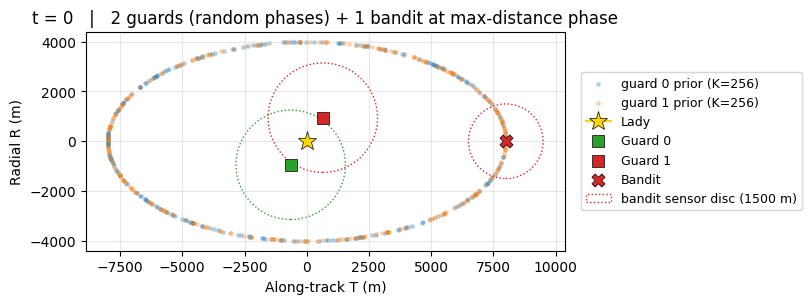

In [9]:
fig, ax = plt.subplots(figsize=(8, 6.5), constrained_layout=True)

s0 = states_over_time[0]
b0 = guard_beliefs_over_time[0]
guards_rt = np.asarray(s0.guards.rt[:, :2])
bandits_rt = np.asarray(s0.bandits.rt[:, :2])

# Per-guard particle clouds over the (single) bandit.
for gi in range(cfg.n_guards):
    p = np.asarray(b0.particles[gi, cfg.n_guards])  # cross-pair: observer gi, target = first bandit
    ax.scatter(p[:, 1], p[:, 0], s=6, alpha=0.25, label=f"guard {gi} prior (K={N_PARTICLES})")

ax.plot(
    0,
    0,
    marker="*",
    color="gold",
    markersize=14,
    markeredgecolor="black",
    markeredgewidth=0.5,
    label="Lady",
    zorder=5,
)
for gi in range(cfg.n_guards):
    ax.scatter(
        guards_rt[gi, 1],
        guards_rt[gi, 0],
        s=80,
        c=f"C{2 + gi}",
        marker="s",
        edgecolors="black",
        linewidths=0.5,
        label=f"Guard {gi}",
        zorder=4,
    )
    ax.add_patch(
        Circle(
            (guards_rt[gi, 1], guards_rt[gi, 0]),
            GUARD_SENSOR_RANGE_M,
            fill=False,
            color=f"C{2 + gi}",
            linestyle=":",
            linewidth=1.0,
        )
    )
ax.scatter(
    bandits_rt[0, 1],
    bandits_rt[0, 0],
    s=90,
    c="C3",
    marker="X",
    edgecolors="black",
    linewidths=0.5,
    label="Bandit",
    zorder=4,
)
ax.add_patch(
    Circle(
        (bandits_rt[0, 1], bandits_rt[0, 0]),
        BANDIT_SENSOR_RANGE_M,
        fill=False,
        color="C3",
        linestyle=":",
        linewidth=1.0,
        label=f"bandit sensor disc ({BANDIT_SENSOR_RANGE_M:.0f} m)",
    )
)

ax.set_xlabel("Along-track T (m)")
ax.set_ylabel("Radial R (m)")
ax.set_aspect("equal")
ax.set_title("t = 0   |   2 guards (random phases) + 1 bandit at max-distance phase")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax.grid(alpha=0.3)
plt.show()

## 9. EXTENSION POINT — Cross-guard belief fusion (the comms hook)

Mahdi specifically asked for a "share particle beliefs to do some
sort of cross-particle filter belief update" mechanism. The package
already provides this: `PFTeamFusion` does a joint resample across
in-contact teammates' particle clouds. The `contact` mask is a
per-teammate boolean — `True` means teammate `i` is participating in
this fusion event.

Two ways to plug it in:

**(a) Manual call (this cell).** Treat any tick on which both guards
see the bandit as a "fusion opportunity": each guard's PF posterior
about the bandit gets joint-resampled with the other's. The fused
cloud is the SIR posterior of the union of both observers. This is
the most direct mapping to a SDec-style "agents broadcast their PF
beliefs and refit". The fusion is `O(n_obs * n_total * K)` and works
inside `jax.lax.scan`, so it's safe to run every tick if you want
continuous sharing rather than event-gated sharing.

**(b) Automatic via `belief_rollout(team_sync_fns=...)`.** Pass a
`BySide(guard=PFTeamFusion(), bandit=...)` and let the rollout fire
fusion every tick using the per-side ground-station contact mask.
This is how the production-side code uses it; see
`belief_rollout` in `orbitalgym.rollout`.

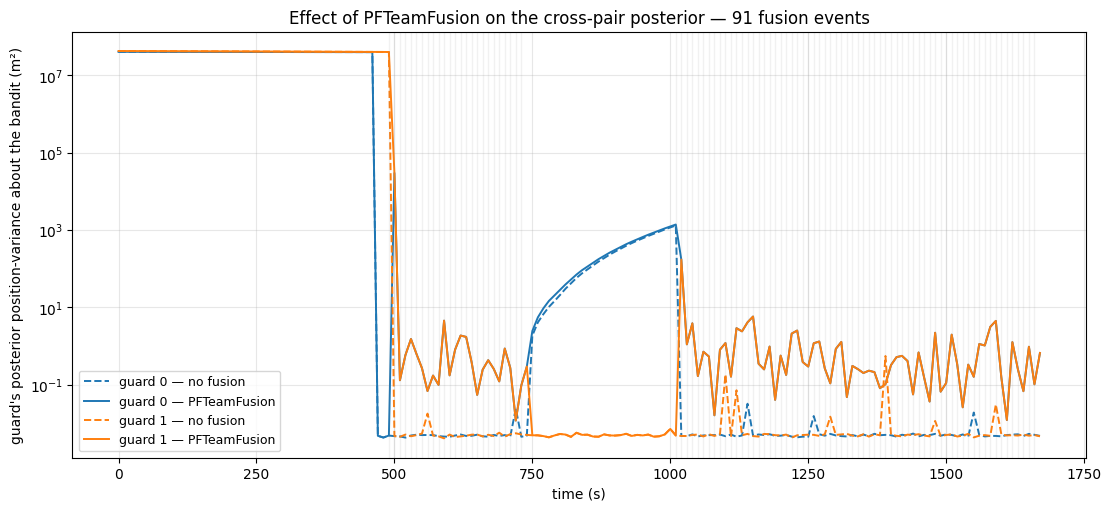

#fusion events: 91 (out of 450 ticks)


In [10]:
fuser = PFTeamFusion()

# Replay the rollout; on every tick where both guards see the bandit,
# fuse their PF beliefs about the bandit. We compute the variance of
# the cross-pair posterior over time, with and without fusion, to show
# the effect quantitatively. (Re-using the rollout we already have for
# the unfused trace; recomputing for fused.)


def _xpair_position_variance(belief, n_self, n_total):
    """Trace of the position-variance for the (observer, opposing-target) cells.

    Returns shape `(n_self, n_total - n_self)` — variance for each
    (observer, opposing target) cell at the *current* belief snapshot.
    """
    weights = jax.nn.softmax(belief.log_weights, axis=-1)  # (n_obs, n_total, K)
    mean = jnp.einsum("...k,...kd->...d", weights, belief.particles)  # (n_obs, n_total, d)
    diff = belief.particles - mean[..., None, :]  # (n_obs, n_total, K, d)
    sq = jnp.sum(diff[..., :2] * diff[..., :2], axis=-1)  # position-only, (n_obs, n_total, K)
    variance = jnp.einsum("...k,...k->...", weights, sq)  # (n_obs, n_total)
    return variance[:, n_self:]  # opposing-target slice


# Match section 7's key-split structure exactly so the two rollouts produce
# the same env trajectory (and therefore the same termination step) — only
# the fusion call differs.
key_fuse = jax.random.PRNGKey(7)
key_fuse, k_reset_f, k_g_init_f, k_b_init_f = jax.random.split(key_fuse, 4)
state_f, _ = env.reset(k_reset_f)
belief_f = guard_pf_init(state_f, Side.GUARD, k_g_init_f)

fused_var_trace = [
    np.asarray(_xpair_position_variance(belief_f, cfg.n_guards, cfg.n_guards + cfg.n_bandits))
]
fusion_events = []
for step in range(n_steps):
    key_fuse, k_g, k_b, k_env, k_g_obs, k_b_obs, k_g_pf, k_b_pf = jax.random.split(key_fuse, 8)
    g_action, _ = guard_policy(None, None, k_g, state_f.t)
    b_action, _ = bandit_policy(
        None, (state_f.bandits.rt, state_f.guards.rt[:, :2]), k_b, state_f.t,
    )
    actions = Actions(sides=BySide(guard=g_action, bandit=b_action))
    step_out = env.step(k_env, state_f, actions)
    next_state = step_out.state
    obs = env.guard_observation_fn(
        next_state,
        actions,
        Side.GUARD,
        env.config,
        k_g_obs,
        next_state.t,
    )
    belief_f = guard_pf_updater(belief_f, obs, g_action.dv, Side.GUARD, k_g_pf)

    # Per-guard contact mask: True iff guard i sees the bandit this tick.
    contact = obs[0].visible[:, cfg.n_guards :].any(axis=-1)  # (n_guards,)
    if bool(contact.sum() > 1):
        belief_f = fuser(belief_f, contact)
        fusion_events.append(step)

    state_f = next_state
    fused_var_trace.append(
        np.asarray(_xpair_position_variance(belief_f, cfg.n_guards, cfg.n_guards + cfg.n_bandits))
    )
    if bool(step_out.episode_done):
        break

# Variance trace for the unfused rollout (computed from the section-7 data).
unfused_var_trace = np.stack(
    [
        np.asarray(_xpair_position_variance(b, cfg.n_guards, cfg.n_guards + cfg.n_bandits))
        for b in guard_beliefs_over_time
    ],
    axis=0,
)
fused_var_trace = np.stack(fused_var_trace, axis=0)

t_axis = np.arange(unfused_var_trace.shape[0]) * cfg.dt

fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
for gi in range(cfg.n_guards):
    ax.plot(
        t_axis,
        unfused_var_trace[:, gi, 0],
        color=f"C{gi}",
        linestyle="--",
        linewidth=1.4,
        label=f"guard {gi} — no fusion",
    )
    ax.plot(
        t_axis,
        fused_var_trace[:, gi, 0],
        color=f"C{gi}",
        linestyle="-",
        linewidth=1.4,
        label=f"guard {gi} — PFTeamFusion",
    )
for ev in fusion_events:
    ax.axvline(ev * cfg.dt, color="C7", alpha=0.10, linewidth=1.0)
ax.set_yscale("log")
ax.set_xlabel("time (s)")
ax.set_ylabel("guard's posterior position-variance about the bandit (m²)")
ax.set_title(
    f"Effect of PFTeamFusion on the cross-pair posterior — {len(fusion_events)} fusion events"
)
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.show()

print(f"#fusion events: {len(fusion_events)} (out of {n_steps} ticks)")

## 10. Animation — multi-guard PF cloud + truth + sensor discs

`RolloutScene` duck-types the belief: anything with `particles` +
`log_weights` arrays gets the scatter-cloud overlay. Both **guards'**
particle clouds about the bandit AND the **bandit's** particle clouds
about each guard render in the same panel — pass both belief
histories via `BySide(guard=..., bandit=...)`. Markers:

- **Faded blue dots** — guards' particle clouds about the bandit
  (per-particle alpha tracks normalized weight).
- **Faded red dots** — bandit's particle clouds about each guard.
- **Open coloured circle** — `belief.mean` for each cross-pair.
- **Coloured squares** — guard truth (one colour per guard).
- **Red X** — bandit truth.
- **Dotted disc** — each guard's range-limited sensor disc.
- **Gold star** — lady (RTN origin).

**Why the cloud lags the truth.** A common surprise: even when the
bandit is inside a guard's sensor disc and detected continuously,
the cloud lags a few hundred meters behind the bandit's true
position. This is structural, not a bug:

- The PF *predicts* particles forward each tick under the dynamics
  `f(x, u, dt)`. For the **cross-pair** (one side's belief about the
  other), `u` is unknown — the guard doesn't observe the bandit's
  commands — so the PF propagates with **`u = 0`** (zero-control HCW).
- The *truth* trajectory is driven by the bandit's glideslope thrust,
  which is decidedly not zero. So the predicted cloud rides the
  natural-motion ring while the truth pulls toward the lady.
- Each detection contributes a single `m=3` position measurement
  with σ=5 m. With process noise ≪ measurement noise, the PF is
  slow to follow a sustained dynamics mismatch — the cloud will
  eventually catch up after several consecutive detections, but
  transient lag during fast manoeuvres is the norm.

To shrink the lag: increase `PROCESS_NOISE_DIAG` (broader cloud →
more weight on each measurement), shorten the no-detection prefix
(wider `GUARD_SENSOR_RANGE_M`), or — for the *bandit's* belief about
the guards — pass the guard's truth `dv` through the PF prediction
(the guard runs `ZeroControl` here, so this is a no-op; if you swap
in a thrusting guard policy you'll need to pass that side's `dv` to
the bandit-side PF updater).

In [11]:
from orbitalgym.env.types import SideTrajectory, Trajectory  # noqa: E402
from orbitalgym.viz.animation import RolloutScene, save_animation  # noqa: E402

states_for_traj = states_over_time[:-1]
guard_beliefs_for_traj = guard_beliefs_over_time[:-1]
bandit_beliefs_for_traj = bandit_beliefs_over_time[:-1]

env_state_stacked = jax.tree_util.tree_map(lambda *xs: jnp.stack(xs, axis=0), *states_for_traj)
guard_actions_stacked = jax.tree_util.tree_map(
    lambda *xs: jnp.stack(xs, axis=0),
    *guard_actions_list,
)
bandit_actions_stacked = jax.tree_util.tree_map(
    lambda *xs: jnp.stack(xs, axis=0),
    *bandit_actions_list,
)
guard_belief_stacked = jax.tree_util.tree_map(
    lambda *xs: jnp.stack(xs, axis=0),
    *guard_beliefs_for_traj,
)
bandit_belief_stacked = jax.tree_util.tree_map(
    lambda *xs: jnp.stack(xs, axis=0),
    *bandit_beliefs_for_traj,
)

T = guard_actions_stacked.dv.shape[0]
empty_obs = jnp.zeros((T, 1))
zeros_T = jnp.zeros(T)  # noqa: N816 — T = number of time steps (math/array-shape convention)
done_T = jnp.zeros(T, dtype=bool)  # noqa: N816

traj_for_anim = Trajectory(
    env_state=env_state_stacked,
    sides=BySide(
        guard=SideTrajectory(
            obs=empty_obs,
            action=guard_actions_stacked,
            reward=zeros_T,
            done=done_T,
            policy_state=None,
        ),
        bandit=SideTrajectory(
            obs=empty_obs,
            action=bandit_actions_stacked,
            reward=zeros_T,
            done=done_T,
            policy_state=None,
        ),
    ),
    episode_done=done_T,
    controlled_side=Side.GUARD,
)
belief_history_for_anim = BySide(guard=guard_belief_stacked, bandit=bandit_belief_stacked)

scene = RolloutScene(
    traj=traj_for_anim,
    cfg=cfg,
    dt=cfg.dt,
    mode="2d",
    show_trail=True,
    show_cubes=True,
    show_sensor_range=True,
    show_thrust=True,  # bandit thrusts toward the lady — show the arrows
    show_belief=True,
    belief_history=belief_history_for_anim,
    belief_particle_size=6.0,
    belief_particle_alpha_min=0.04,
    belief_particle_alpha_max=0.7,
    title_prefix="LBG 2-guard demo — ",
    figsize=(8.5, 7.0),
)
print(
    f"frames = {scene.n_frames}, axis_limit = {scene.axis_limit_m:.0f} m, mode = {scene.resolved_mode}"  # noqa: E501
)

out_dir = _repo_root / "outputs"
out_dir.mkdir(exist_ok=True)
out_path = out_dir / "lbg_two_guard_pf_demo.mp4"
save_animation(scene, str(out_path), fps=12, dpi=110)
print(f"Saved animation to {out_path}")

from IPython.display import Video  # noqa: E402

Video(str(out_path), embed=False)

frames = 167, axis_limit = 8800 m, mode = 2d
Saved animation to /Users/duncan/repos/OrbitalGym/outputs/lbg_two_guard_pf_demo.mp4


## 11. Multi-rollout statistics

A single rollout is a noisy sample of the joint distribution over
(guard ICs, bandit IC, observation noise, PF resampling, action
stochasticity). To get a stable read on how the current policies
perform, run `N_ROLLOUTS` independent episodes (each with a different
seed -> different stratified-random guard phases) and aggregate.

The stats collected per episode:

- **min bandit-to-lady distance** — how close the bandit got to its
  goal (smaller = bandit win).
- **min guard-to-bandit distance** — how close any guard got to the
  bandit (smaller = guard win).
- **#close encounters** (guard within `CATCH_RADIUS_M * 5` of bandit) —
  counts ticks per episode where the guards were near a "could
  catch" event without necessarily catching.
- **#close-to-lady passes** (bandit within `BREACH_RADIUS_M * 5` of
  the lady) — counts ticks per episode where the bandit was
  threatening a breach.
- **termination reason**: `catch` / `breach` / `max_distance` /
  `truncated_max_steps`.

This is also where you'd plug in alternative policies and compare —
e.g. "ZeroControl guards" vs "MCTS guards" vs "SDecZero guards" on
the same set of seeds.

In [ ]:
N_ROLLOUTS = 20  # bump to 100+ for tight error bars
CLOSE_ENCOUNTER_RADIUS_M = CATCH_RADIUS_M * 5.0  # 5x catch radius — "near-catch" event
CLOSE_TO_LADY_RADIUS_M = BREACH_RADIUS_M * 5.0  # 5x breach radius — "near-breach" event


def run_one_episode(seed: int):
    """Run a single rollout with the given seed; return per-episode stats."""
    cfg_seed = make_cfg(guard_obs_fn=guard_obs_fn, bandit_obs_fn=bandit_obs_fn, seed=seed)
    env_seed = OrbitalGymEnv(cfg_seed)
    bandit_policy_seed = GlideslopeToLadyWithAvoidance.build(
        dt=cfg_seed.dt,
        mean_motion=N_MOTION,
        max_dv_mps=BANDIT_MAX_DV_MPS,
        avoidance_gain=BANDIT_AVOIDANCE_GAIN,
        avoidance_sigma_m=BANDIT_AVOIDANCE_SIGMA_M,
        n_vehicles=cfg_seed.n_bandits,
        command_cls=env_seed.bandit_command_cls,
    )
    guard_policy_seed = ZeroControl(
        n_vehicles=cfg_seed.n_guards,
        command_cls=env_seed.guard_command_cls,
    )

    key = jax.random.PRNGKey(seed)
    key, k_reset, k_g_init, k_b_init = jax.random.split(key, 4)
    state, _ = env_seed.reset(k_reset)
    guard_belief = guard_pf_init(state, Side.GUARD, k_g_init)
    bandit_belief = bandit_pf_init(state, Side.BANDIT, k_b_init)

    n_steps_local = int(cfg_seed.max_horizon_s / cfg_seed.dt)
    min_d_gb = float("inf")
    min_d_bl = float("inf")
    n_close_encounters = 0
    n_close_to_lady = 0
    cum_guard_reward = 0.0
    cum_bandit_reward = 0.0
    termination = "truncated_max_steps"
    final_step = n_steps_local
    for step in range(n_steps_local):
        key, k_g, k_b, k_env, k_g_obs, k_b_obs, k_g_pf, k_b_pf = jax.random.split(key, 8)
        g_action, _ = guard_policy_seed(None, None, k_g, state.t)
        b_action, _ = bandit_policy_seed(
            None, (state.bandits.rt, state.guards.rt[:, :2]), k_b, state.t,
        )
        actions = Actions(sides=BySide(guard=g_action, bandit=b_action))
        step_out = env_seed.step(k_env, state, actions)
        next_state = step_out.state

        # PF updates aren't strictly needed for stats but kept so the
        # rollout matches the section-7 dynamics exactly.
        g_obs = env_seed.guard_observation_fn(
            next_state,
            actions,
            Side.GUARD,
            env_seed.config,
            k_g_obs,
            next_state.t,
        )
        b_obs = env_seed.bandit_observation_fn(
            next_state,
            actions,
            Side.BANDIT,
            env_seed.config,
            k_b_obs,
            next_state.t,
        )
        guard_belief = guard_pf_updater(guard_belief, g_obs, g_action.dv, Side.GUARD, k_g_pf)
        bandit_belief = bandit_pf_updater(bandit_belief, b_obs, b_action.dv, Side.BANDIT, k_b_pf)

        state = next_state
        cum_guard_reward += float(step_out.outputs.guard.reward)
        cum_bandit_reward += float(step_out.outputs.bandit.reward)

        g_pos = state.guards.rt[:, :2]
        b_pos = state.bandits.rt[:, :2]
        d_gb = float(jnp.min(jnp.linalg.norm(g_pos[:, None, :] - b_pos[None, :, :], axis=-1)))
        d_bl = float(jnp.min(jnp.linalg.norm(b_pos, axis=-1)))
        all_pos = jnp.concatenate([g_pos, b_pos], axis=0)
        d_far = float(jnp.max(jnp.linalg.norm(all_pos, axis=-1)))
        if d_gb < min_d_gb:
            min_d_gb = d_gb
        if d_bl < min_d_bl:
            min_d_bl = d_bl
        if d_gb < CLOSE_ENCOUNTER_RADIUS_M:
            n_close_encounters += 1
        if d_bl < CLOSE_TO_LADY_RADIUS_M:
            n_close_to_lady += 1

        # Termination (first-fired wins).
        if termination == "truncated_max_steps":
            if d_gb < cfg_seed.reward_fn.catch_radius_m:
                termination = "catch"
            elif d_bl < cfg_seed.reward_fn.breach_radius_m:
                termination = "breach"
            elif d_far > MAX_DISTANCE_TERMINATION_M:
                termination = "max_distance"
        if bool(step_out.episode_done):
            final_step = step + 1
            break

    return {
        "seed": seed,
        "min_d_gb": min_d_gb,
        "min_d_bl": min_d_bl,
        "n_close_encounters": n_close_encounters,
        "n_close_to_lady": n_close_to_lady,
        "cum_guard_reward": cum_guard_reward,
        "cum_bandit_reward": cum_bandit_reward,
        "termination": termination,
        "final_step": final_step,
    }


# Run the sweep. Each rollout is ~1-2s on CPU after JIT warm-up.
import time  # noqa: E402

t0 = time.time()
episode_stats = [run_one_episode(seed) for seed in range(N_ROLLOUTS)]
t1 = time.time()
print(f"Ran {N_ROLLOUTS} episodes in {t1 - t0:.1f}s ({(t1 - t0) / N_ROLLOUTS:.2f} s/episode).")

### 11a. Termination breakdown

In [ ]:
from collections import Counter  # noqa: E402

term_counter = Counter(e["termination"] for e in episode_stats)
total = sum(term_counter.values())
print("Termination outcomes (count -- fraction):")
for reason in ("catch", "breach", "max_distance", "truncated_max_steps"):
    n = term_counter.get(reason, 0)
    print(f"  {reason:24s} {n:4d}   {n / total:5.1%}")

### 11b. Per-episode distance statistics

Two histograms summarise the closest approach in each direction:
`min_d_gb` (any guard ever this close to the bandit) and `min_d_bl`
(the bandit ever this close to the lady). The catch radius and
breach radius are drawn as vertical guides.

In [ ]:
min_d_gb_arr = np.array([e["min_d_gb"] for e in episode_stats])
min_d_bl_arr = np.array([e["min_d_bl"] for e in episode_stats])
n_close_enc_arr = np.array([e["n_close_encounters"] for e in episode_stats])
n_close_lady_arr = np.array([e["n_close_to_lady"] for e in episode_stats])
final_step_arr = np.array([e["final_step"] for e in episode_stats])

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].hist(min_d_gb_arr, bins=15, color="C2", edgecolor="black")
axes[0].axvline(
    CATCH_RADIUS_M,
    color="red",
    linestyle="--",
    linewidth=1.0,
    label=f"catch radius ({CATCH_RADIUS_M:.0f} m)",
)
axes[0].set_xlabel("min guard-to-bandit distance over episode (m)")
axes[0].set_ylabel("# episodes")
axes[0].set_title(f"closest guard-bandit approach ({N_ROLLOUTS} episodes)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(min_d_bl_arr, bins=15, color="C3", edgecolor="black")
axes[1].axvline(
    BREACH_RADIUS_M,
    color="red",
    linestyle="--",
    linewidth=1.0,
    label=f"breach radius ({BREACH_RADIUS_M:.0f} m)",
)
axes[1].set_xlabel("min bandit-to-lady distance over episode (m)")
axes[1].set_ylabel("# episodes")
axes[1].set_title(f"closest bandit-lady approach ({N_ROLLOUTS} episodes)")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.show()

print(
    f"min guard-to-bandit (mean over episodes): {min_d_gb_arr.mean():.1f} m  (std {min_d_gb_arr.std():.1f})"  # noqa: E501
)
print(
    f"min bandit-to-lady  (mean over episodes): {min_d_bl_arr.mean():.1f} m  (std {min_d_bl_arr.std():.1f})"  # noqa: E501
)
print(
    f"#close encounters    (mean / episode):    {n_close_enc_arr.mean():.1f}  (within {CLOSE_ENCOUNTER_RADIUS_M:.0f} m)"  # noqa: E501
)
print(
    f"#close-to-lady passes (mean / episode):   {n_close_lady_arr.mean():.1f}  (within {CLOSE_TO_LADY_RADIUS_M:.0f} m)"  # noqa: E501
)
print(
    f"mean episode length: {final_step_arr.mean():.0f} steps  "
    f"(t = {final_step_arr.mean() * cfg.dt:.0f} s)"
)

## 12. Suggested Next Steps

- **Sensor-range sweep.** Set `BANDIT_SENSOR_RANGE_M` to 0 and rerun:
  the bandit becomes blind, but its lady-seeking policy is
  open-loop on its own state, so the qualitative behaviour barely
  changes. Now set it to 5000 m and rerun: the bandit's PF over the
  guards collapses every step.

- **Sensor-noise sweep.** Increase `GUARD_SIGMA_RANGE` to 50 m or
  100 m. The guards' PF posteriors become broader after each
  detection — you'll see a higher steady-state cross-pair variance
  in section 9.

- **Capture-radius sweep.** Set `CATCH_RADIUS_M = 200.0` and rerun
  under a chasing guard policy. The terminal events fire earlier
  and the cumulative guard reward jumps.

- **Custom guard policy.** Replace `ZeroControl` in section 4 with
  a chasing policy that thrusts toward the cross-pair belief mean.
  The `LeadInterceptPursuer` heuristic is a good starting point —
  adapt its agent_view layout to the manual loop here, or move the
  whole rollout to `belief_rollout` to get the full belief plumbing.

- **SDecZero integration.** Build a multi-agent policy that takes a
  `BySide`-shaped belief as input. Move the rollout to
  `belief_rollout(team_sync_fns=BySide(guard=PFTeamFusion(), bandit=None), ...)`
  so the cross-guard fusion fires automatically on every tick where
  the (per-side) ground-station contact mask is open.

- **Belief-fusion ablation.** Run the section-9 fusion with
  `PFTeamFusion()` versus `EKFTeamFusion()` (would require switching
  the guard belief to KF/EKF in section 5) and compare the rate of
  variance reduction at fusion events.